In [1]:
# Cell 1 — Imports
import sys
import os

# This tells Jupyter where to find the config folder
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import pandas as pd
import numpy as np
import json
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm
from config.config import CLEANED_SYMPTOM, BIOBERT_MODEL, SAVED_WEIGHTS_DIR

print("All imports successful")
print("Project root:", os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

All imports successful
Project root: C:\Users\Lenovo\healthguard-ai


In [2]:
df = pd.read_csv(CLEANED_SYMPTOM / "symptoms_diseases_clean.csv")
print(f"Total records: {len(df)}")
print(f"Unique diseases: {df['disease'].nunique()}")

with open(CLEANED_SYMPTOM / "disease2id.json") as f:
    disease2id = json.load(f)

NUM_LABELS = len(disease2id)
print(f"Number of classes: {NUM_LABELS}")


Total records: 304
Unique diseases: 41
Number of classes: 41


In [3]:
class SymptomDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df["symptoms_text"].tolist()
        self.labels = [disease2id[d] for d in df["disease"]]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [4]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
train_dataset = SymptomDataset(train_df, tokenizer)
val_dataset   = SymptomDataset(val_df,   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

C:\Users\Lenovo\healthguard-ai\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--dmis-lab--biobert-v1.1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Train: 243 | Val: 61


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL, num_labels=NUM_LABELS
)
optimizer = AdamW(model.parameters(), lr=2e-5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training on: cpu


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

In [6]:
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f}")

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████| 16/16 [03:28<00:00, 13.06s/it]


Epoch 1 — Loss: 3.7446


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████| 16/16 [03:21<00:00, 12.61s/it]


Epoch 2 — Loss: 3.5392


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████████| 16/16 [03:24<00:00, 12.80s/it]

Epoch 3 — Loss: 3.3280


In [7]:
model.eval()
correct = 0
total   = 0
with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

print(f"Validation Accuracy: {correct/total*100:.2f}%")

Validation Accuracy: 24.59%


In [8]:
torch.save(model.state_dict(), SAVED_WEIGHTS_DIR / "disease_predictor.pt")
print("Model saved to models/saved_weights/disease_predictor.pt")

Model saved to models/saved_weights/disease_predictor.pt


In [9]:
# Cell 9 — Improved Training (run this instead of cells 5 and 6)

from transformers import get_linear_schedule_with_warmup

# ── Reload model fresh ────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL, num_labels=NUM_LABELS
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

# ── Learning rate scheduler ───────────────────────
EPOCHS = 10
total_steps = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Training loop with scheduler ──────────────────
best_accuracy = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Evaluate after each epoch ──────────────────
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    accuracy = correct / total * 100
    print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f} — Val Accuracy: {accuracy:.2f}%")

    # Save best model only
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(
            model.state_dict(),
            SAVED_WEIGHTS_DIR / "disease_predictor.pt"
        )
        print(f"  ✅ New best model saved — {accuracy:.2f}%")

print(f"\nTraining complete. Best accuracy: {best_accuracy:.2f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████████| 16/16 [04:04<00:00, 15.28s/it]


Epoch 1 — Loss: 3.7241 — Val Accuracy: 4.92%
  ✅ New best model saved — 4.92%


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████████| 16/16 [03:16<00:00, 12.26s/it]


Epoch 2 — Loss: 3.5377 — Val Accuracy: 21.31%
  ✅ New best model saved — 21.31%


...

Epoch 8 — Loss: 2.0097 — Val Accuracy: 85.25%
  ✅ New best model saved — 85.25%


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████| 16/16 [03:27<00:00, 12.99s/it]


Epoch 9 — Loss: 1.9263 — Val Accuracy: 86.89%
  ✅ New best model saved — 86.89%


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████| 16/16 [03:26<00:00, 12.90s/it]


Epoch 10 — Loss: 1.8737 — Val Accuracy: 86.89%

Training complete. Best accuracy: 86.89%


Min samples per disease: 5
Max samples per disease: 10
Mean samples per disease: 7.4


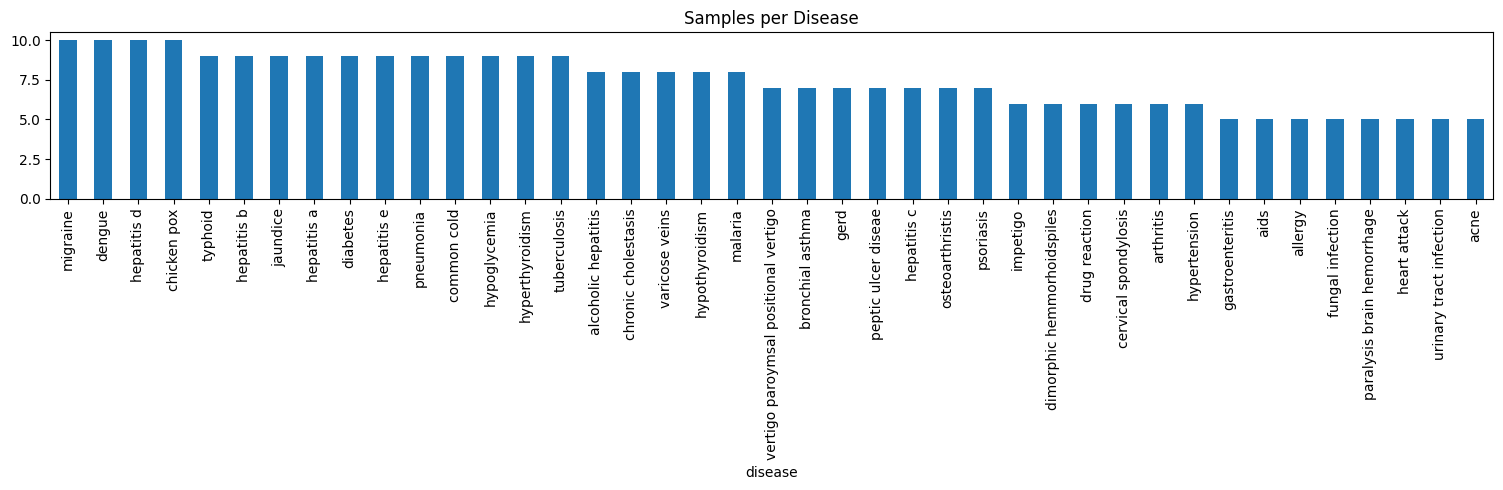

In [10]:
# Cell 10 — Check class balance
import matplotlib.pyplot as plt

disease_counts = df["disease"].value_counts()
print(f"Min samples per disease: {disease_counts.min()}")
print(f"Max samples per disease: {disease_counts.max()}")
print(f"Mean samples per disease: {disease_counts.mean():.1f}")

disease_counts.plot(kind="bar", figsize=(15,5), title="Samples per Disease")
plt.tight_layout()
plt.show()